**Table of contents**<a id='toc0_'></a>    
- [Antibunching: 4 fluorophores, different distances, OET](#toc1_)    
  - [Preparation](#toc1_1_)    
  - [Generation](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Antibunching: 4 fluorophores, different distances, OET](#toc0_)

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams

import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.routines as rt
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

saving_at = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_12_multi_f_antibunching\OET_RET_continuous"

## <a id='toc1_1_'></a>[Preparation](#toc0_)

In [4]:
def generate_data(distance, n, rng):
    PARAMS_ADJ = {
        k: v for k, v in rt.PARAMS_DSTORM.items() if k != "energy_transfer_parameters"
    }

    fluorophores = fl.construct_fluorophores(
        name="cy5_dna", count=4, distance=distance, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
    transitions = fluorophore_system.load_transitions(
        bleaching=True,
        summarize=True,
        energy_transfer=True,
        **PARAMS_ADJ,
        energy_transfer_parameters={
            "overwrite": {"off": [1, 1e-4], "s1": [0.01, 0]},
            "exclude": ["s0"],
        },
    )

    side_factor = 3**6 / distance**6
    diag_factor = 3**6 / distance**6 / 8
    radical_ET_side = tr.Transition(
        transition_type=tr.TransitionType.R_FRET_1,
        rate=1e9 * side_factor,
        fluorophore_ids=[
            (0, 1),
            (0, 2),
            (1, 0),
            (1, 3),
            (2, 0),
            (2, 3),
            (3, 1),
            (3, 2),
        ],
    )
    radical_ET_diag = tr.Transition(
        transition_type=tr.TransitionType.R_FRET_1,
        rate=1e9 * diag_factor,
        fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)],
    )
    transitions[list(transitions.keys())[1]].append(radical_ET_side)
    transitions[list(transitions.keys())[2]].append(radical_ET_diag)

    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.adjust_rates(change_dict={6: 5e5})

    transition_set.finalize()

    for i in range(n):
        emis = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
        emis.simulate(transition_set, frames=300000, store_time_points=True)
        emis.event_time_series.to_frame().to_parquet(
            saving_at + rf"\event_time_series_{distance}nm_{i}.parquet"
        )
        np.save(
            saving_at + rf"\event_time_points_{distance}nm_{i}.npy",
            emis.event_time_points,
        )

## <a id='toc1_2_'></a>[Generation](#toc0_)

In [5]:
rng = np.random.default_rng(1)
generate_data(3, 10, rng)
generate_data(6, 10, rng)
generate_data(9, 10, rng)
generate_data(18, 10, rng)

In [67]:
rng = np.random.default_rng(42)

all_data_coincidence = []
all_data_coincidence_truncated = []
all_data_time_series = []
all_mins = []
identifiers = ["3nm", "6nm", "9nm", "18nm"]
for j, id in enumerate(identifiers):
    all_data_coincidence.append([])
    all_data_coincidence_truncated.append([])
    all_data_time_series.append([])
    all_mins.append([])
    for file in Path(saving_at).iterdir():
        if f"event_time_points_{id}_" in file.name:
            event_time_points = np.load(file)
            event_time_points_ = event_time_points
            hist, bins = fcs_p.coincidence(
                event_time_points_,
                tau_max=1e-7,
                bin_width=5e-10,
                seed=rng,
                method="numba",
            )
            all_mins[j].append(np.min(hist) / np.mean(hist[:180]))
            all_data_coincidence[j].append([hist, bins])
            min_index = np.where(event_time_points_ > 20e-3)[0][0]
            event_time_points_truncated = event_time_points_[min_index:]
            hist_truncated, bins_truncated = fcs_p.coincidence(
                event_time_points_truncated,
                tau_max=1e-7,
                bin_width=5e-10,
                seed=rng,
                method="numba",
            )
            all_data_coincidence_truncated[j].append([hist_truncated, bins_truncated])
        if f"event_time_series_{id}_" in file.name:
            emis = em.Emissions()
            emis.event_time_series = pd.read_parquet(file)[0]
            rt.emission_post_processing(emis, seed=rng)
            all_data_time_series[j].append(emis)

Text(0.5, 0.04, 'Delay ($10^-7$ x s)')

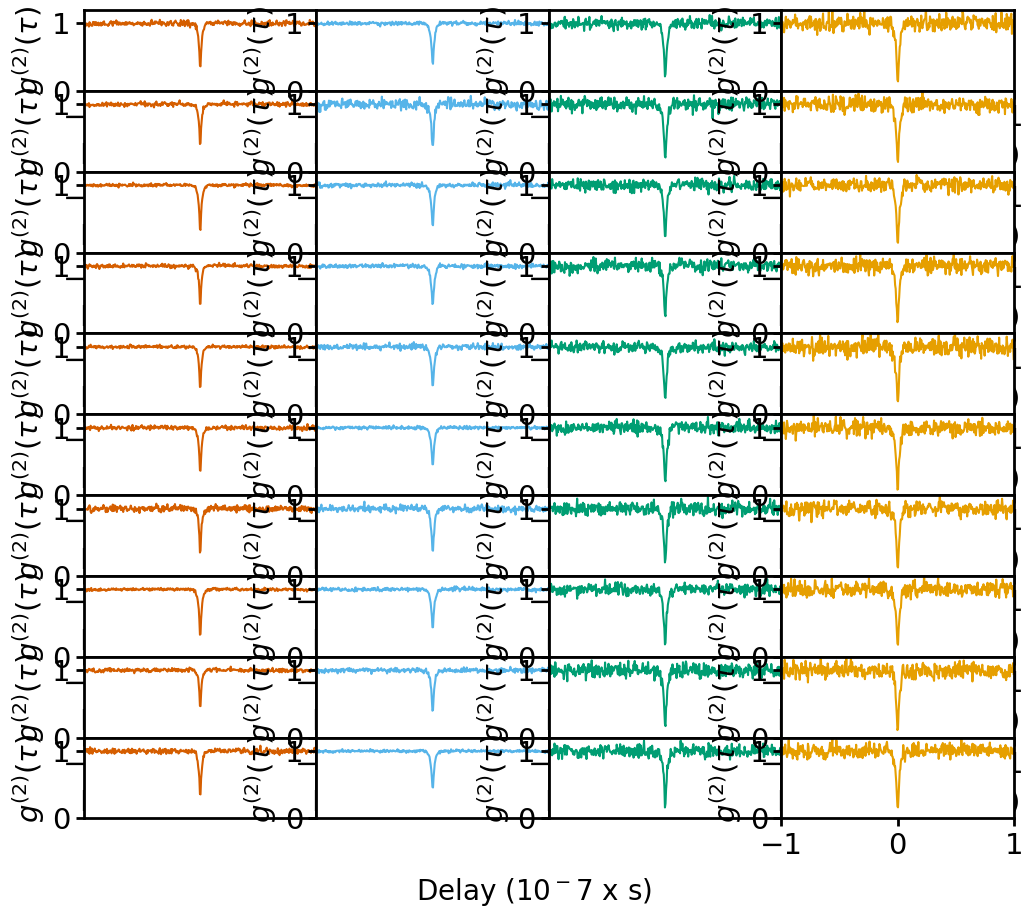

In [69]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(10, 4, wspace=0, hspace=0)
fig = plt.figure(figsize=(12, 10.5))
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

identifiers = ["3nm", "6nm", "9nm", "18nm"]
for j, _ in enumerate(identifiers):
    for k, (hist, bins) in enumerate(all_data_coincidence[j]):
        ax = fig.add_subplot(gs[k, j])
        fi.universal_figure(
            axes=ax,
            type_="line",
            data=[bins, hist / np.mean(hist[:180])],
            ylim=[0, 1.2],
            ylabel=r"$g^{(2)}(\tau)$",
            xlim=[-1e-7, 1e-7],
            xlabel="Delay (s)",
            color=colors[j],
            tick_style_x="sci",
        )
    if j != len(identifiers) - 1:
        ax.set_xticklabels([])
        ax.set_xticks([])
    ax.set_xlabel("")

fig.text(0.5, 0.04, r"Delay ($10^-7$ x s)", ha="center", va="center", fontsize=20)

# fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])

Text(0.5, 0.04, 'Delay ($10^-7$ x s)')

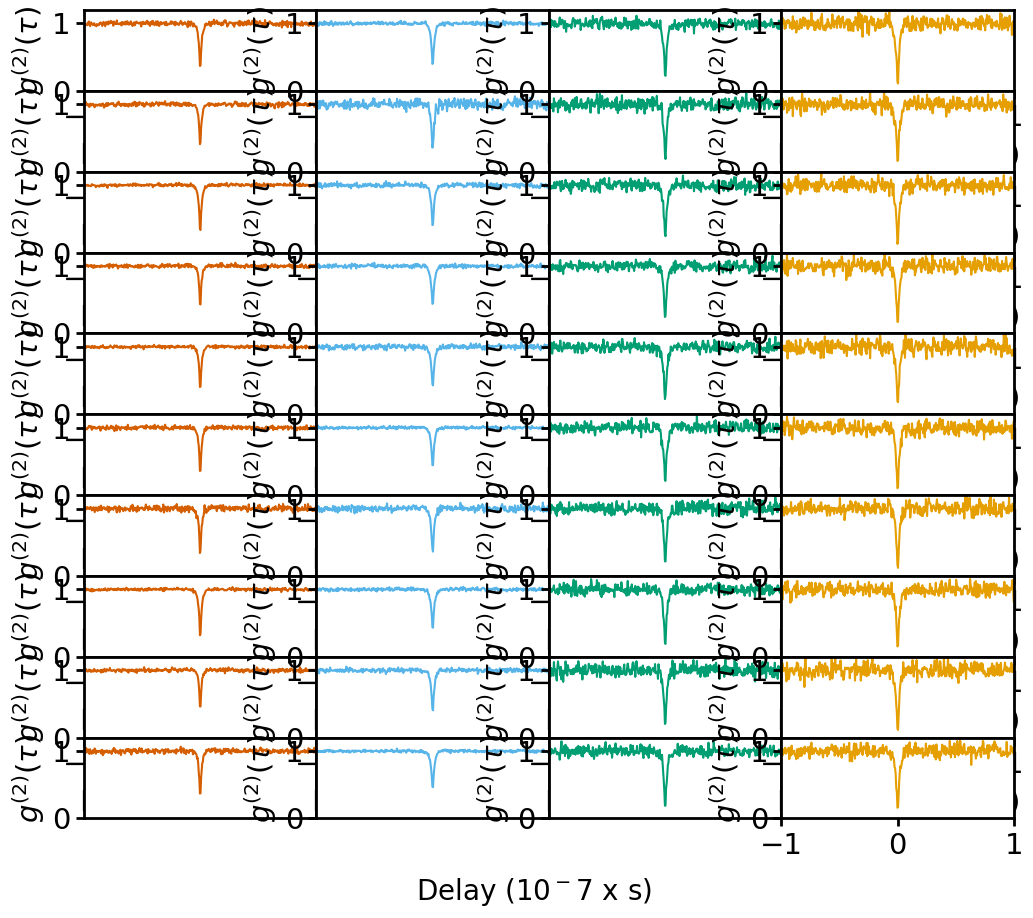

In [70]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(10, 4, wspace=0, hspace=0)
fig = plt.figure(figsize=(12, 10.5))
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

identifiers = ["3nm", "6nm", "9nm", "18nm"]
for j, _ in enumerate(identifiers):
    for k, (hist, bins) in enumerate(all_data_coincidence_truncated[j]):
        ax = fig.add_subplot(gs[k, j])
        fi.universal_figure(
            axes=ax,
            type_="line",
            data=[bins, hist / np.mean(hist[:180])],
            ylim=[0, 1.2],
            ylabel=r"$g^{(2)}(\tau)$",
            xlim=[-1e-7, 1e-7],
            xlabel="Delay (s)",
            color=colors[j],
            tick_style_x="sci",
        )
    if j != len(identifiers) - 1:
        ax.set_xticklabels([])
        ax.set_xticks([])
    ax.set_xlabel("")

fig.text(0.5, 0.04, r"Delay ($10^-7$ x s)", ha="center", va="center", fontsize=20)

# fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])

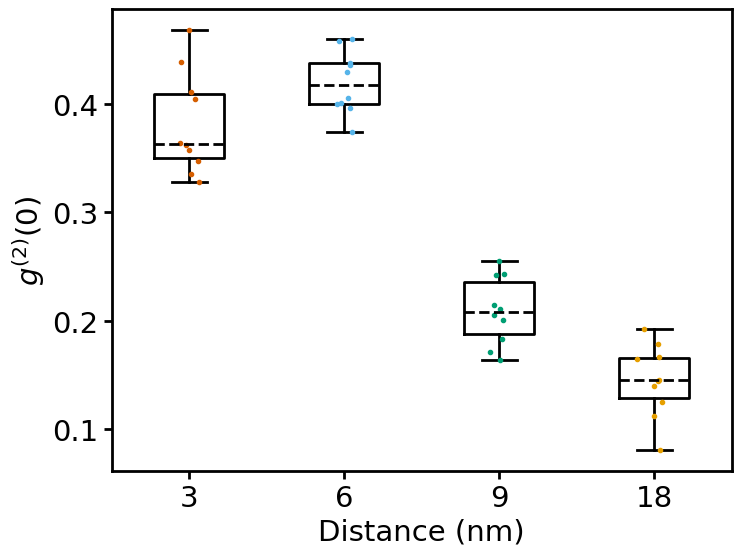

In [ ]:
rcParams["axes.linewidth"] = 2
rng = np.random.default_rng(42)
fig, ax = plt.subplots(figsize=(8, 6))
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]
fi.universal_figure(
    axes=ax,
    data=all_mins,
    type_="boxplot",
    ylabel=r"$g^{(2)}(0)$",
    xlabel="Distance (nm)",
    boxprops=dict(lw=2),
    whiskerprops=dict(lw=2),
    capprops=dict(lw=2),
    medianprops=dict(color="black", ls="--", lw=2),
    xticklabels={"labels": ["3", "6", "9", "18"]},
)
for i, group in enumerate(all_mins):
    y = group
    x = rng.normal(i + 1, 0.04, size=len(y))
    ax.plot(x, y, ".", alpha=1, color=colors[i])
plt.show()

In pulsed excitation, no fluorophore can be excited twice within a pulse, which is the reason for larger g²(0) in continuous excitation

Text(0.5, 0.04, 'Delay ($10^-7$ x s)')

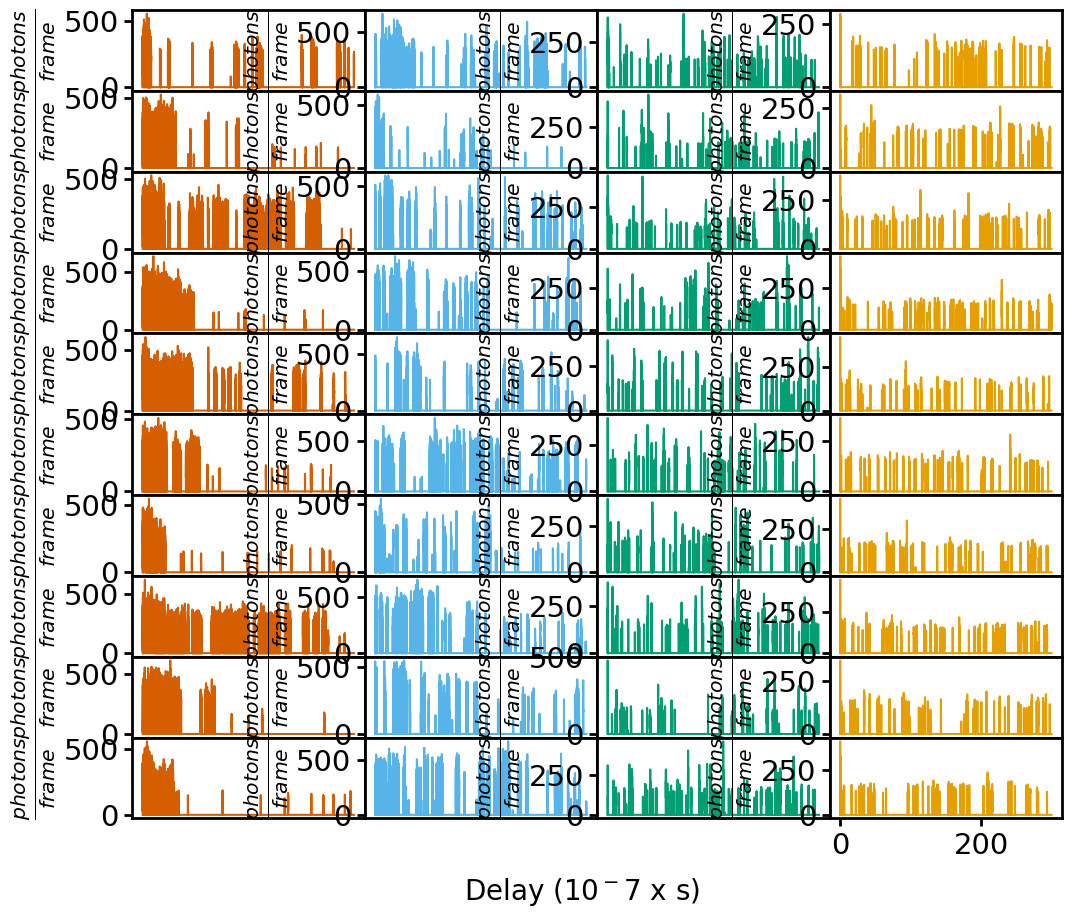

In [27]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(10, 4, wspace=0, hspace=0)
fig = plt.figure(figsize=(12, 10.5))
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

identifiers = ["3nm", "6nm", "9nm", "18nm"]
for j, _ in enumerate(identifiers):
    for k, emis in enumerate(all_data_time_series[j]):
        ax = fig.add_subplot(gs[k, j])
        emis.plot_time_series(axes=ax, color=colors[j])
    if j != len(identifiers) - 1:
        ax.set_xticklabels([])
        ax.set_xticks([])
    ax.set_xlabel("")

fig.text(0.5, 0.04, r"Delay ($10^-7$ x s)", ha="center", va="center", fontsize=20)

# fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])